# 06 · Gate interactions on the QAOA benchmark

**Computes.** All $\binom{13}{2}=78$ order-2 gate interaction indices (Grabisch--Roubens) for the \texttt{qshaptools} QAOA circuit, from the channel-mixture multilinear extension by Owen integration ($M=\lceil(m-1)/2\rceil=6$, $2|S|M=24$ extension evaluations per pair) versus exact $2^{13}$ enumeration. The energy is **interaction-dominated**: low-cardinality (single-/double-block) gate coalitions leave $\langle H\rangle\approx 0$, so it is realized only by the full init$\times$cost$\times$mixer combination.

**Produces.** `figures/fig_gate_int.png` (interaction heatmap + first-order vs total-interaction) and `results/06.json`.

**Seed.** Deterministic (no sampling).

In [1]:
import os, sys
sys.path.insert(0, os.path.abspath(".."))
import numpy as np
import matplotlib.pyplot as plt
import tnshapq as T
from tnshapq import exact, owen, metrics
from tnshapq.io_utils import save_results, savefig

np.random.seed(0)
plt.rcParams.update({'font.size': 13, 'axes.titlesize': 13, 'axes.labelsize': 13,
                     'xtick.labelsize': 12, 'ytick.labelsize': 12, 'legend.fontsize': 11})

In [2]:
qc, H, game = T.build_qaoa_example()
m = game.n
M = T.threshold_M(m, order=2)                       # ceil((13-1)/2) = 6
table = exact.exact_value_table(game)               # 2^13 enumeration
I_exact = exact.exact_interactions(table, m)        # GR order-2, all 78 pairs
phi1 = exact.exact_shapley(table, m)                # first-order, for comparison
print(f"m={m}; interaction threshold M={M}; built 2^{m}={2**m} value table")

m=13; interaction threshold M=6; built 2^13=8192 value table


In [3]:
# Channel-mixture Owen interactions (M=6): exact at 24 evaluations per pair
I_owen, pairs, ev_pair = owen.gate_owen_interactions(game, M)
iu = np.triu_indices(m, 1)
max_err = metrics.max_abs_err(I_owen[iu], I_exact[iu])
print(f"Owen M={M}: {len(pairs)} pairs, {ev_pair} evals/pair, max|err| vs exact = {max_err:.2e}")

Owen M=6: 78 pairs, 24 evals/pair, max|err| vs exact = 4.44e-15


In [4]:
# Interaction-dominance via block ablations: dropping the cost OR the mixer block leaves
# <H>=0, so the energy is realized only by the full init x cost x mixer combination.
first_on_q, last_on_q = {}, {}
for gi, ci in enumerate(qc.data):
    for q in [qc.find_bit(b).index for b in ci.qubits]:
        first_on_q.setdefault(q, gi); last_on_q[q] = gi
init = sorted(set(first_on_q.values()))      # first gate on each qubit (Hadamard init layer)
mixer = sorted(set(last_on_q.values()))       # last gate on each qubit (RX mixer layer)
cost = [i for i in range(m) if i not in init and i not in mixer]
def energy(keep):
    z = np.array([1 if i in keep else 0 for i in range(m)], np.int8)
    return float(game.value(z))
ablations = {"init only": energy(init),
             "init+cost (drop mixer)": energy(init + cost),
             "init+mixer (drop cost)": energy(init + mixer),
             "full": energy(list(range(m)))}
v_empty = float(table[0]); v_full = ablations["full"]
max_ablation = max(abs(v) for k, v in ablations.items() if k != "full")
tot_first = float(np.sum(np.abs(phi1)))
tot_int = float(np.sum(np.abs(I_exact[iu])))
for k, v in ablations.items():
    print(f"  {k:24s} <H> = {v:+.4f}")
print(f"max |<H>| over single-/double-block ablations = {max_ablation:.2e}  (full = {v_full:.3f})")
print(f"sum|first-order|={tot_first:.3f}   sum|interactions|={tot_int:.3f}   "
      f"ratio int/first = {tot_int/tot_first:.2f}")

  init only                <H> = +0.0000
  init+cost (drop mixer)   <H> = +0.0000
  init+mixer (drop cost)   <H> = +0.0000
  full                     <H> = +1.8128
max |<H>| over single-/double-block ablations = 5.55e-16  (full = 1.813)
sum|first-order|=2.888   sum|interactions|=13.355   ratio int/first = 4.62


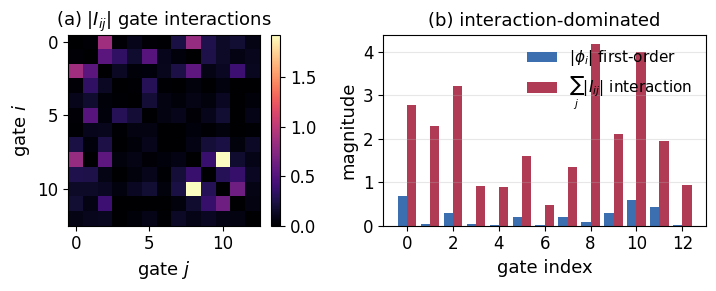

saved figures/fig_gate_int.png


In [5]:
# Figure: (a) |interaction| heatmap; (b) first-order vs total interaction per gate
fig, (a1, a2) = plt.subplots(1, 2, figsize=(8.0, 3.1), gridspec_kw={'width_ratios': [1, 1.15]})
im = a1.imshow(np.abs(I_exact), cmap='magma')
a1.set_title('(a) $|I_{ij}|$ gate interactions'); a1.set_xlabel('gate $j$'); a1.set_ylabel('gate $i$')
fig.colorbar(im, ax=a1, fraction=0.046, pad=0.04)

tot_int_i = np.sum(np.abs(I_exact), axis=1)
xb = np.arange(m); wid = 0.4
a2.bar(xb - wid/2, np.abs(phi1), wid, color='#3b6fb0', label=r'$|\phi_i|$ first-order')
a2.bar(xb + wid/2, tot_int_i, wid, color='#b03b54', label=r'$\sum_j |I_{ij}|$ interaction')
a2.set_xticks(xb[::2]); a2.set_xlabel('gate index'); a2.set_ylabel('magnitude')
a2.set_title('(b) interaction-dominated'); a2.legend(frameon=False); a2.grid(alpha=0.3, axis='y')
fig.tight_layout()
savefig(fig, 'fig_gate_int.png')
plt.show()
print("saved figures/fig_gate_int.png")

In [6]:
res = {
    "task": "gate order-2 interactions (qshaptools QAOA, m=13)",
    "m": m, "n_pairs": len(pairs), "M": int(M), "evals_per_pair": int(ev_pair),
    "enum_evals": int(2**m), "max_err": float(max_err),
    "v_empty": float(v_empty), "v_full": float(v_full),
    "ablations": {k: float(v) for k, v in ablations.items()},
    "max_abs_ablation_energy": float(max_ablation),
    "sum_first_order": tot_first, "sum_interactions": tot_int,
    "interaction_ratio": float(tot_int / tot_first),
    "threshold_ok": bool(max_err < 1e-12),
}
save_results("06", res)
print("saved results/06.json")

saved results/06.json


In [7]:
# Verification: Owen M=6 reproduces all 78 GR interactions to machine precision
np.testing.assert_allclose(I_owen[iu], I_exact[iu], atol=1e-12, rtol=0)
print(f"PASS  Owen M={M} reproduces all {len(pairs)} GR gate interactions: max err {max_err:.2e}, "
      f"{ev_pair} evals/pair.")
print(f"      interaction-dominated: sum|I|/sum|phi| = {tot_int/tot_first:.2f}; "
      f"single-/double-block ablations |<H>| <= {max_ablation:.1e} vs full {v_full:.3f}.")

PASS  Owen M=6 reproduces all 78 GR gate interactions: max err 4.44e-15, 24 evals/pair.
      interaction-dominated: sum|I|/sum|phi| = 4.62; single-/double-block ablations |<H>| <= 5.6e-16 vs full 1.813.
